### Preparing a dataset for supervised instruction finetuning

In [1]:
import json
import os
import requests


def load_file(file_path):
    with open(file_path, 'r', encoding = 'utf-8',) as file:
        data = json.load(file)
    return data

file_path = r"D:\Aryan\Projects\TrainGPT\GPT\data\qna_data_new.json"
data = load_file(file_path)
print("Number of entries:", len(data))

Number of entries: 11086


In [2]:
print(data[1])

{'instruction': 'What is the name of the company this report pertains to?', 'input': 'Power to Propel the Future\n\nSolar Industries India Limited Annual Report 2024-25\n\nAbout the Report\n\nThis is Solar\'s Integrated Annual Report for FY 2024-25, providing a comprehensive assessment of financial and non-financial metrics. This report covers the financial year from April 01, 2024, to March 31, 2025 .\n\nThis Report is prepared in accordance with the International Integrated Reporting Framework published by the International Integrated Reporting Council (IIRC). We have also followed guidelines and commitments outlined in the GRI Standards, Sustainable Development Goals (SDGs), and other relevant standards and frameworks.\n\nForward-looking statements\n\nSome information in this report may contain forward-looking statements which include statements regarding Company\'s expected financial position and results of operations, business plans and prospects, and are generally identified by f

In [3]:
print(data[1].keys())

dict_keys(['instruction', 'input', 'output'])


In [4]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    # input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text 

In [5]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What does the Partnership Chakra embody?

### Response:
The Partnership Chakra embodies Solar's collaborative spirit.


In [6]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
As of what date were the internal financial controls deemed adequate and functioning effectively?

### Response:
As of March 31, 2025, the internal financial controls were deemed to be both adequate and functioning effectively.


In [7]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]


In [8]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 9423
Validation set length: 555
Test set length: 1108


### Organizing data into training batches

In [9]:
import torch 
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data


        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [10]:
from tokenizer_base.regex1 import RegexTokenizer 
def load_custom_tokenizer(model_path):
    """
    Loads the custom regex.model and regex.vocab files.
    """
    tokenizer = RegexTokenizer()
    # Loading typically expects the prefix without extension if following minbpe patterns
    # or the specific .model file.
    tokenizer.load(model_path) 
    return tokenizer

# Usage
# If your files are 'regex.model' and 'regex.vocab' in the current directory:
tokenizer = load_custom_tokenizer(r"D:\Aryan\Projects\TrainGPT\GPT\tokenizer_base\models\regex.model")

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(device)
def custom_collate_draft_1(batch, pad_token_id=50256, device=device):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)
    print(batch_max_length)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        print([pad_token_id] * (batch_max_length - len(new_item)))
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
            )
        # Via padded[:-1], we remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (the extra padding token will be relevant in later codes)
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [12]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

6
[]
[50256, 50256, 50256]
[50256, 50256]
tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='cuda:0')


In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(device)
def custom_collate_draft_2(batch, pad_token_id=50256, device=device):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)
    print(batch_max_length)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        print([pad_token_id] * (batch_max_length - len(new_item)))
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
            )
        # Via padded[:-1], we remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (the extra padding token will be relevant in later codes)
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [14]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

6
[]
[50256, 50256, 50256]
[50256, 50256]
tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='cuda:0')
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]], device='cuda:0')


In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(device)
def custom_collate_fn(batch, pad_token_id=50256, device=device, ignore_index= -100,allowed_max_length=None):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)
    # print(batch_max_length)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        # print([pad_token_id] * (batch_max_length - len(new_item)))
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )

        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])
        
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [16]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='cuda:0')
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]], device='cuda:0')


In [17]:
logits_1 = torch.tensor(
    [[-1.0,1.0],
     [-0.5,1.5]]
)
targets_1 = torch.tensor([0,1])
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [18]:
logits_2 = torch.tensor(
    [[-1.0,1.0],
     [-0.5,1.5],
     [-0.5,1.5]]
)
targets_2 = torch.tensor([0,1,1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [19]:
targets_3 = torch.tensor([0, 1, -100])
 
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


### Creating data loaders for an instruction dataset

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [21]:
device

device(type='cuda')

In [22]:
from functools import partial
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)


In [23]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data , tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last= True,
    num_workers = num_workers
)

In [24]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader= DataLoader(
    val_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [25]:
train_loader

In [26]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)
    print(inputs[1])
    print(targets[1])
    

Train loader:
torch.Size([8, 67]) torch.Size([8, 67])
tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198,  4821,   284,   262,  4732,    11,   644,
          318,  2672,   329,  5150, 26360,   284,   307, 32013,    30,   198,
          198, 21017, 18261,    25,   198,  4677,   305,  2100,   379,   262,
         5079,  2276,  3249,   318,  2672,   329,  5150, 26360,   284,   307,
        32013,    13, 50256, 50256, 50256, 50256, 50256], device='cuda:0')
tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198,  4821,   284,   262,  4732,    11,   644,   318,
         2672,   329,  5150, 26360,   284,   307, 32013,    30,   198,   198,
        21017, 18261,    25,   198,  4677,   305,  2100,   379,   262,  5079,
         2276

In [27]:
inputs[0]

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198,  2061,   318,   262,  8354,   286,   262,
         6647,  4750,   287,   262,  4732,    30,   198,   198, 21017, 18261,
           25,   198,   464,  8354,   286,   262,  6647,   318,  6355, 18848,
           13, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256], device='cuda:0')

In [28]:
targets[0]

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198,  2061,   318,   262,  8354,   286,   262,  6647,
         4750,   287,   262,  4732,    30,   198,   198, 21017, 18261,    25,
          198,   464,  8354,   286,   262,  6647,   318,  6355, 18848,    13,
        50256,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100], device='cuda:0')

In [29]:
tokenizer.decode(inputs[0].tolist())

'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nWhat is the scope of the regulations mentioned in the context?\n\n### Response:\nThe scope of the regulations is corporate governance.<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>'

In [30]:
# tokenizer.decode(targets[0].tolist())

In [31]:
from new_previous_chapters import GPTModel



GPT_CONFIG_400M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 1024,        # Embedding dimension
    "n_heads": 16,         # Number of attention heads
    "n_layers": 24,        # Number of layers
    "drop_rate": 0.0,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

checkpoint = torch.load("model_and_optimizer_400m.pth", weights_only=True)
model = GPTModel(GPT_CONFIG_400M)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [32]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the significance of the phrase 'unless otherwise stated'?


In [33]:
from new_previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)
inference_device = torch.device("cuda")
model.to(inference_device)
model.eval();

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special = {"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())


token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(inference_device),
    max_new_tokens=35,
    context_size=GPT_CONFIG_400M["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [34]:
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the significance of the phrase 'unless otherwise stated'? of the Company's Responsibilities for the preparation of the Standalone Financial Statements

| Sr. No. No. | Name of the Listed Companies Act, 2013 read


### 7.6 Finetuning the LLM on instruction data

In [35]:
from new_previous_chapters import (
    calc_loss_loader,
    train_model_simple
)
model.to("cuda")

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 8.507305812835693
Validation loss: 8.737614822387695


In [36]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00002, weight_decay=0.1)

num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 6.431, Val loss 6.763
Ep 1 (Step 000005): Train loss 4.099, Val loss 4.207
Ep 1 (Step 000010): Train loss 3.393, Val loss 3.464
Ep 1 (Step 000015): Train loss 2.898, Val loss 3.044
Ep 1 (Step 000020): Train loss 2.739, Val loss 2.848
Ep 1 (Step 000025): Train loss 2.522, Val loss 2.740
Ep 1 (Step 000030): Train loss 2.565, Val loss 2.662
Ep 1 (Step 000035): Train loss 2.437, Val loss 2.601
Ep 1 (Step 000040): Train loss 2.527, Val loss 2.555
Ep 1 (Step 000045): Train loss 2.416, Val loss 2.533
Ep 1 (Step 000050): Train loss 2.447, Val loss 2.539
Ep 1 (Step 000055): Train loss 2.375, Val loss 2.537
Ep 1 (Step 000060): Train loss 2.321, Val loss 2.476
Ep 1 (Step 000065): Train loss 2.064, Val loss 2.441
Ep 1 (Step 000070): Train loss 2.395, Val loss 2.436
Ep 1 (Step 000075): Train loss 2.359, Val loss 2.462
Ep 1 (Step 000080): Train loss 2.194, Val loss 2.443
Ep 1 (Step 000085): Train loss 2.162, Val loss 2.409
Ep 1 (Step 000090): Train loss 2.089, Val loss

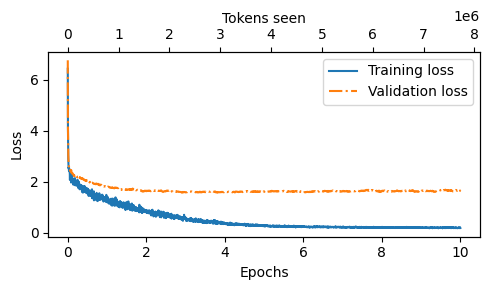

In [37]:
from new_previous_chapters import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### 7.7 Extracting and saving responses

In [38]:
for entry in test_data[:3]:

    print
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=GPT_CONFIG_400M["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")
    

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the overall subject matter of Note 19?

Correct response:
>> The overall subject matter of Note 19 is tax expenses and their reconciliation with accounting profit based on the Indian domestic tax rate for the years ended March 31, 2025 and March 31, 2024.

Model response:
>> Note 19 addresses other income.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What was the accounting profit before tax for the year ending March 31, 2025?

Correct response:
>> The accounting profit before tax for the year ending March 31, 2025, was 1,733.19.

Model response:
>> The accounting profit before tax for the year ending March 31, 2025 was 1.05.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriat

In [39]:
inp = {
    "instruction" : "What is the significance of the phrase 'unless otherwise stated'?"
}

input_text = format_input(inp)
print(input_text)
token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=GPT_CONFIG_400M["context_length"],
        eos_id=50256
    )

generated_text = token_ids_to_text(token_ids, tokenizer)
response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
print(f"\nModel response:\n>> {response_text.strip()}")
print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the significance of the phrase 'unless otherwise stated'?

Model response:
>> The phrase 'unless otherwise stated' indicates that some amounts may be presented in a different unit of measurement.
-------------------------------------
